# **Regulatory Affairs of Road Accident Data 2020 India**

## Tools Used  

- **Python**  
  Core programming language used for data analysis, preprocessing, and model building  

- **Pandas**  
  Used for data loading, cleaning, preprocessing, and handling structured accident datasets  

- **NumPy**  
  Used for numerical computations and array operations  

- **Matplotlib**  
  Used for basic data visualization such as plots and charts  

- **Seaborn**  
  Used for advanced statistical visualizations like correlation heatmaps and data distributions  

- **Scikit-learn**  
  Used for:  
  - Model building (Random Forest Regressor)  
  - Data preprocessing (LabelEncoder)  
  - Model evaluation (Mean Squared Error, R² Score)  
  - Data splitting (train_test_split)  

## Problem Definition  

This project focuses on analyzing road accident data across major Indian cities to identify the key causes and patterns of accidents. It examines factors such as traffic violations, road conditions, and environmental influences. The objective is to understand how these factors impact accident outcomes like injuries and fatalities. The insights can help in improving road safety and policy-making.

In [1]:
# Importing libraries used for data manipulation and visualization
import pandas as pd
import numpy as np

# Libraries for plotting graphs
import matplotlib.pyplot as plt
import seaborn as sns

# Libraries for Machine Learning
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Set visual style for graphs
sns.set(style="whitegrid")

## Load Dataset  

The dataset contains road accident data for major cities in India, including details such as cause category, subcategory, accident outcomes, and incident counts. It is used to analyze accident patterns and understand the relationship between different causes and their impact on injuries, fatalities, and overall accident frequency.

In [2]:
# Load the dataset containing road accident data for Indian cities
df = pd.read_csv("/content/Regulatory Affairs of Road Accident Data 2020 India.csv")

# Display first few rows to understand the dataset
df.head()

,Million Plus Cities,Cause category,Cause Subcategory,Outcome of Incident,Count
0,Agra,Traffic Control,Flashing Signal/Blinker,Greviously Injured,0.0
1,Agra,Traffic Control,Flashing Signal/Blinker,Minor Injury,0.0
2,Agra,Traffic Control,Flashing Signal/Blinker,Persons Killed,0.0
3,Agra,Traffic Control,Flashing Signal/Blinker,Total Injured,0.0
4,Agra,Traffic Control,Flashing Signal/Blinker,Total number of Accidents,0.0



## Dataset Overview & Missing Values Explanation  

- The dataset contains **9550 rows and 5 columns**, representing road accident data across major cities in India.  
- Most columns are **categorical (object type)**, while **"Count" is numerical (float)** representing the number of incidents.  

### Data Quality  
- All columns have complete data **except "Count"**, which has **3 missing values**.  
- This is confirmed using `df.isnull().sum()`, where only the "Count" column shows missing entries.  

### Statistical Summary  
- The **average accident count** is around **103**, with values ranging from **0 to 3148**, indicating high variation in accident frequency.  

### Handling Missing Values  
- Missing values in the "Count" column are replaced with **0 using `fillna(0)`**, assuming no recorded accidents for those entries.  
- After this step, the dataset becomes **complete with no missing values**, making it ready for analysis and modeling.

In [3]:
# Display number of rows and columns
df.shape

# Display data types and non-null values
df.info()

# Display statistical summary of numerical columns
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9550 entries, 0 to 9549
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Million Plus Cities  9550 non-null   object 
 1   Cause category       9550 non-null   object 
 2   Cause Subcategory    9550 non-null   object 
 3   Outcome of Incident  9550 non-null   object 
 4   Count                9547 non-null   float64
dtypes: float64(1), object(4)
memory usage: 373.2+ KB


,Count
count,9547.000000
mean,103.627632
std,275.189303
min,0.000000
25%,0.000000
50%,12.000000
75%,70.500000
max,3148.000000


In [4]:
# Checking if any values are missing in the dataset
df.isnull().sum()

,0
Million Plus Cities,0
Cause category,0
Cause Subcategory,0
Outcome of Incident,0
Count,3


In [5]:
# Replace missing accident counts with 0
df['Count'] = df['Count'].fillna(0)

# **Exploratory Data Analysis (EDA)**

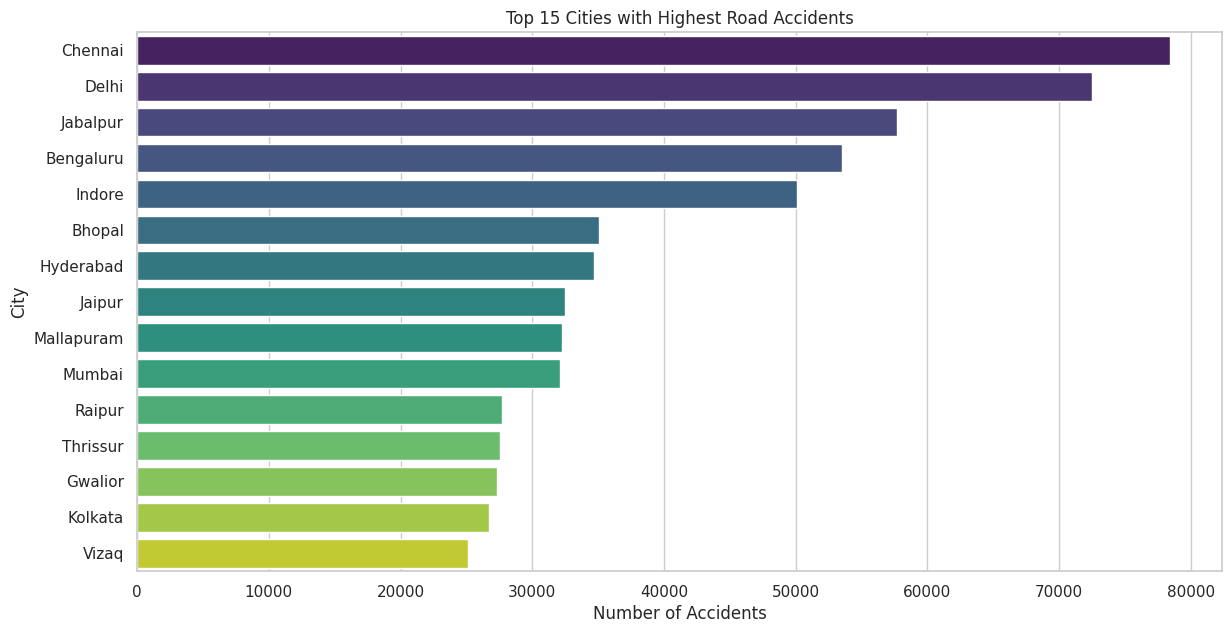

In [7]:
# Group dataset by city and calculate total accidents
city_accidents = df.groupby('Million Plus Cities')['Count'].sum()

# Sort cities in descending order
city_accidents = city_accidents.sort_values(ascending=False)

# Plot
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,7))

sns.barplot(
    x=city_accidents.values[:15],
    y=city_accidents.index[:15],
    hue=city_accidents.index[:15],
    palette="viridis",
    legend=False
)

plt.title("Top 15 Cities with Highest Road Accidents")
plt.xlabel("Number of Accidents")
plt.ylabel("City")

plt.show()

## Top 15 Cities with Highest Road Accidents  

### What this chart shows  
This chart displays the top 15 cities in India with the highest number of road accidents, based on total accident counts aggregated from the dataset. It highlights how accidents are distributed across major cities.

### Key observations  
- A few cities have significantly higher accident counts compared to others  
- Accident distribution is uneven, with certain cities contributing more to total incidents  
- Major urban cities tend to dominate the top positions  

### Business insight  
The concentration of accidents in specific cities suggests higher traffic density, urban congestion, or weaker traffic management in those areas. These cities may require more attention in terms of road safety measures and infrastructure improvements.

### Actionable recommendation  
- Focus road safety campaigns and awareness programs in high-accident cities  
- Improve traffic management systems and enforcement in these regions  
- Analyze city-specific causes to implement targeted safety measures  

### Key takeaway  
Road accidents are heavily concentrated in a few major cities, indicating the need for targeted interventions to reduce accident rates and improve urban road safety.

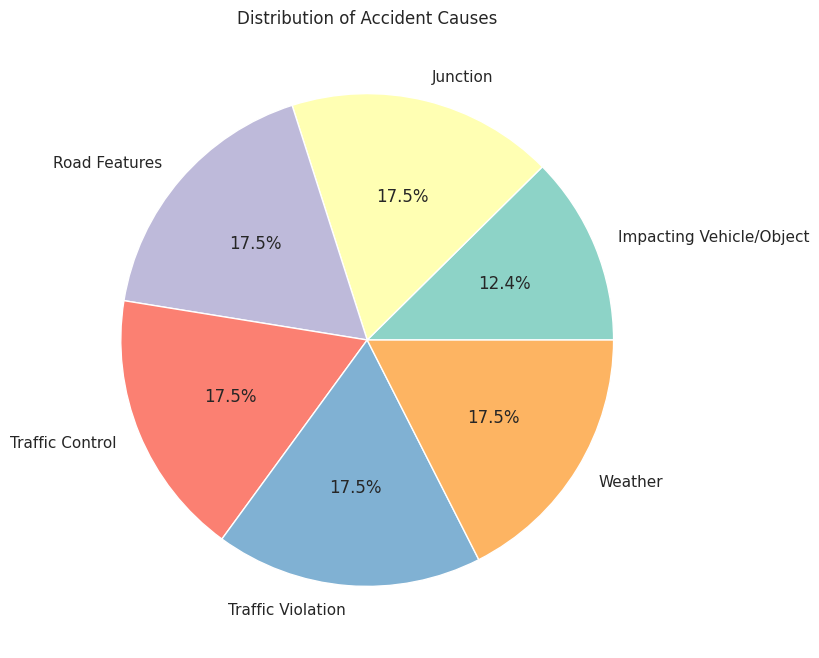

In [8]:
# Calculate total accidents for each cause category
cause_counts = df.groupby('Cause category')['Count'].sum()

# Create pie chart showing accident causes
plt.figure(figsize=(8,8))

plt.pie(
    cause_counts,
    labels=cause_counts.index,
    autopct='%1.1f%%',
    colors=sns.color_palette("Set3")
)

plt.title("Distribution of Accident Causes")

plt.show()

## Distribution of Accident Causes  

### What this chart shows  
This pie chart represents the proportion of different accident causes based on total accident counts. It shows how each cause category contributes to overall road accidents.

### Key observations  
- Certain cause categories contribute a larger share of accidents  
- The distribution highlights dominant factors such as traffic violations, road features, or vehicle-related causes  
- Some categories have relatively smaller contributions, indicating less frequent causes  

### Business insight  
The variation in accident causes suggests that specific factors play a major role in road safety issues. Understanding these dominant causes can help authorities prioritize interventions and resource allocation.

### Actionable recommendation  
- Focus on reducing the most common causes through stricter regulations and awareness campaigns  
- Improve infrastructure and traffic control in areas with high accident causes  
- Conduct deeper analysis on top contributing categories for targeted solutions  

### Key takeaway  
Road accidents are not evenly distributed across causes, with a few key factors responsible for the majority of incidents, highlighting areas for focused safety improvements.

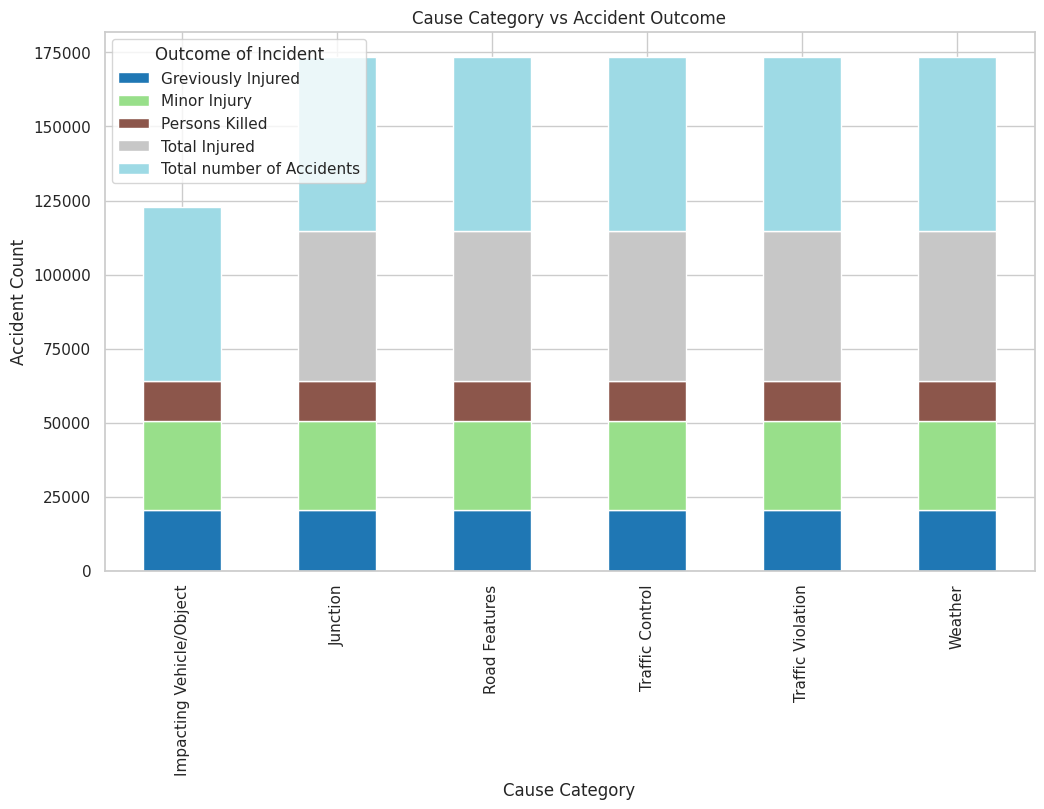

In [ ]:
# Create pivot table showing relationship between cause and outcome
cause_outcome = df.groupby(
    ['Cause category','Outcome of Incident']
)['Count'].sum().unstack()

# Plot stacked bar chart
cause_outcome.plot(
    kind='bar',
    stacked=True,
    figsize=(12,7),
    colormap='tab20'
)

plt.title("Cause Category vs Accident Outcome")
plt.xlabel("Cause Category")
plt.ylabel("Accident Count")

plt.show()

## Cause Category vs Accident Outcome  

### What this chart shows  
This stacked bar chart illustrates the relationship between different accident cause categories and their outcomes (such as injuries, fatalities, and total accidents). It shows how each cause contributes to various types of accident outcomes.

### Key observations  
- Some cause categories lead to higher numbers of severe outcomes like deaths or serious injuries  
- Other causes are more associated with minor injuries or overall accident counts  
- The distribution varies across categories, indicating different levels of risk  

### Business insight  
Different accident causes have different impacts on severity, meaning not all causes are equally dangerous. Identifying high-risk causes helps in prioritizing safety measures and policy interventions.

### Actionable recommendation  
- Focus on high-risk cause categories that lead to severe outcomes (fatalities, serious injuries)  
- Implement stricter enforcement and preventive measures for these causes  
- Use targeted awareness campaigns based on specific accident causes  

### Key takeaway  
Accident outcomes vary significantly across cause categories, highlighting the importance of targeting high-risk causes to reduce severe incidents and improve road safety.

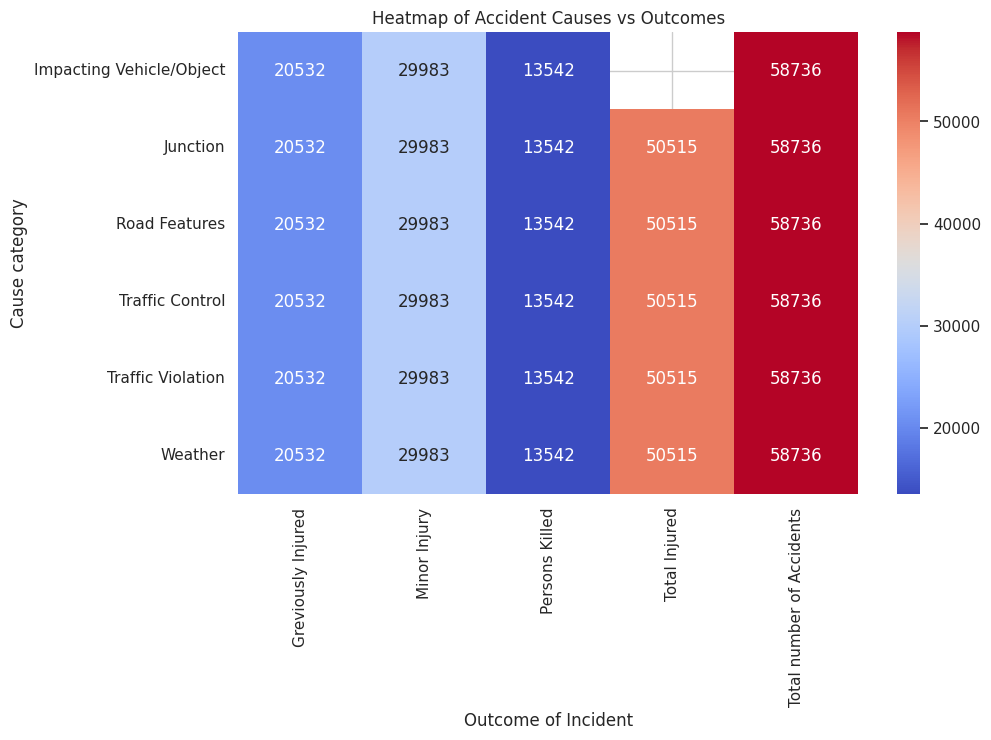

In [ ]:
# Create pivot table for heatmap visualization
pivot = pd.pivot_table(
    df,
    values='Count',
    index='Cause category',
    columns='Outcome of Incident',
    aggfunc='sum'
)

# Plot heatmap
plt.figure(figsize=(10,6))

sns.heatmap(
    pivot,
    annot=True,
    cmap="coolwarm",
    fmt=".0f"
)

plt.title("Heatmap of Accident Causes vs Outcomes")

plt.show()

## Heatmap of Accident Causes vs Outcomes  

### What this chart shows  
This heatmap visualizes the relationship between accident cause categories and their outcomes. It displays the intensity of accident counts using color variations, making it easy to identify patterns and high-impact areas.

### Key observations  
- Darker regions indicate higher accident counts for specific cause-outcome combinations  
- Certain causes are strongly associated with severe outcomes like fatalities and serious injuries  
- Some categories show relatively lower impact across all outcomes  

### Business insight  
The heatmap helps quickly identify which causes contribute most to critical accident outcomes. This allows stakeholders to focus on the most impactful problem areas rather than treating all causes equally.

### Actionable recommendation  
- Prioritize interventions for cause-outcome pairs with the highest intensity  
- Strengthen safety measures and enforcement in high-risk categories  
- Use data-driven strategies to allocate resources effectively  

### Key takeaway  
A few cause categories dominate severe accident outcomes, highlighting the need for targeted safety measures to reduce high-impact incidents.

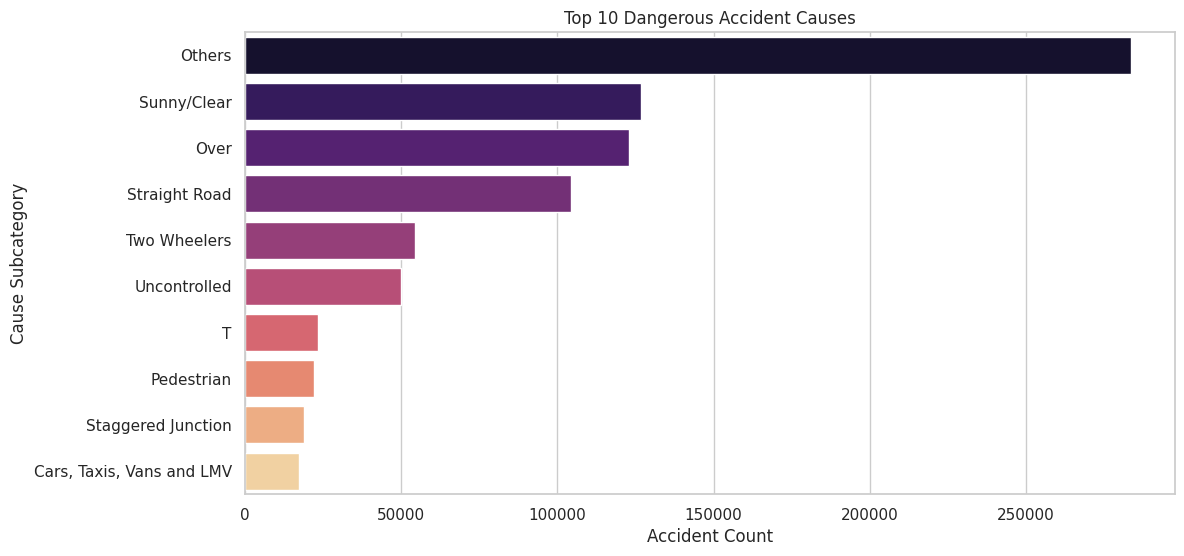

In [10]:
# Calculate total accidents by cause subcategory
top_causes = df.groupby('Cause Subcategory')['Count'].sum()

# Sort and take top 10
top_causes = top_causes.sort_values(ascending=False).head(10)

# Plot
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_causes.values,
    y=top_causes.index,
    hue=top_causes.index,
    palette="magma",
    legend=False
)

plt.title("Top 10 Dangerous Accident Causes")
plt.xlabel("Accident Count")

plt.show()

## Top 10 Dangerous Accident Causes  

### What this chart shows  
This bar chart displays the top 10 accident causes based on their total occurrence. It highlights which specific cause subcategories contribute the most to road accidents.

### Key observations  
- A few causes dominate the majority of accidents  
- Certain factors like traffic violations or road conditions appear more frequently  
- There is a noticeable gap between the top causes and less frequent ones  

### Business insight  
The concentration of accidents around specific causes indicates key problem areas that significantly impact road safety. Addressing these major causes can lead to a substantial reduction in overall accidents.

### Actionable recommendation  
- Implement stricter rules and enforcement for top accident causes  
- Improve road infrastructure and fix high-risk conditions  
- Run targeted awareness campaigns addressing specific risky behaviors  

### Key takeaway  
A small number of accident causes contribute to a large portion of incidents, making them critical focus areas for improving road safety.

# **ML MODEL**


In [13]:
# Machine learning models require numerical data
# Convert categorical columns into numeric labels

le = LabelEncoder()

df_ml = df.copy()

df_ml['City'] = le.fit_transform(df_ml['Million Plus Cities'])
df_ml['CauseCategory'] = le.fit_transform(df_ml['Cause category'])
df_ml['CauseSub'] = le.fit_transform(df_ml['Cause Subcategory'])
df_ml['Outcome'] = le.fit_transform(df_ml['Outcome of Incident'])

In [14]:
# Independent variables (features)
X = df_ml[['City','CauseCategory','CauseSub','Outcome']]

# Dependent variable (target)
y = df_ml['Count']

In [15]:
# Split dataset into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
# Create Random Forest regression model
model = RandomForestRegressor(n_estimators=200)

# Train the model using training data
model.fit(X_train, y_train)

# Predict accident counts for test data
pred = model.predict(X_test)

In [17]:
# Calculate Mean Squared Error
mse = mean_squared_error(y_test, pred)

# Calculate R-squared score
r2 = r2_score(y_test, pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 21234.434497200586
R2 Score: 0.6934986717360876


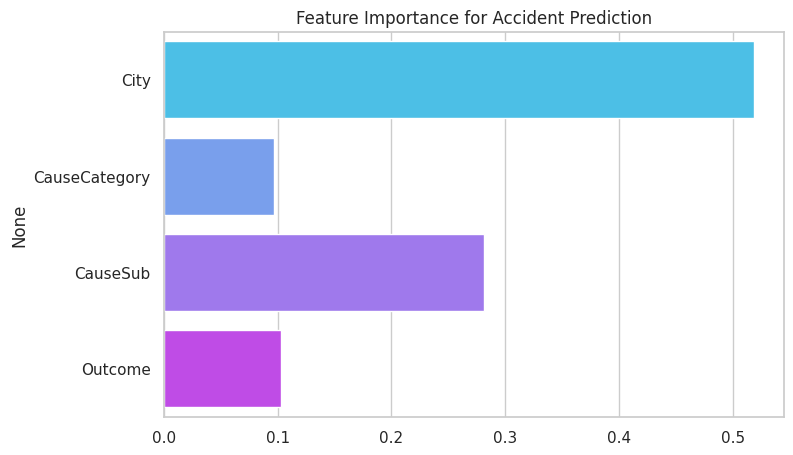

In [18]:
# Train model (example using Random Forest)
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X, y)

# Get feature importance
importance = model.feature_importances_
features = X.columns

# Plot
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    x=importance,
    y=features,
    hue=features,
    palette="cool",
    legend=False
)

plt.title("Feature Importance for Accident Prediction")

plt.show()

This graph shows the significance of various features used in the model for the machine learning prediction of the accident count.
From the above chart, we can infer that the City feature has the highest importance, which implies that the City where the accident occurred is a major factor for the accident count.
The subcategory of the cause of the accident is the second most important feature, which implies that the accident count is affected by the cause of the accident.
On the other hand, the cause category of the accident and the accident outcome have less importance for the prediction.

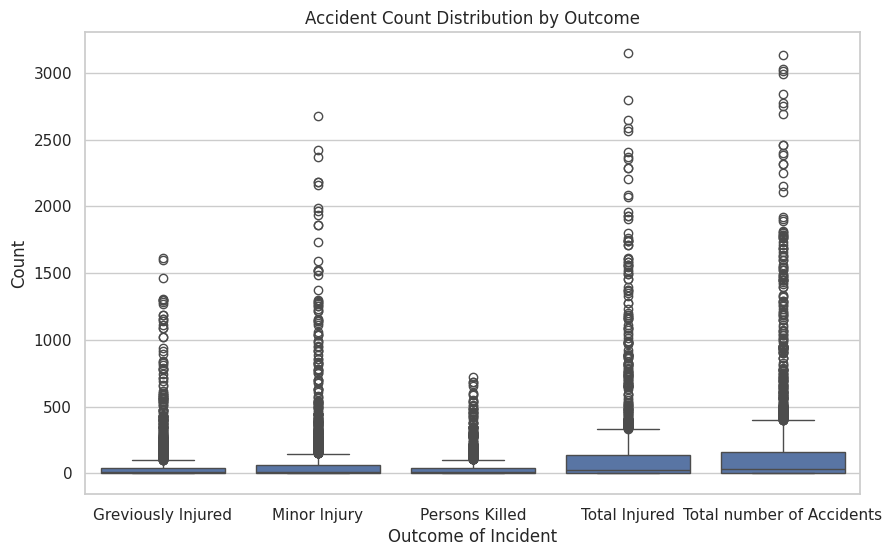

In [ ]:
# Box plot to observe accident count distribution for each outcome
plt.figure(figsize=(10,6))

sns.boxplot(
    x='Outcome of Incident',
    y='Count',
    data=df
)

plt.title("Accident Count Distribution by Outcome")

plt.show()

This box plot illustrates the number of accidents in various cases such as grievous injuries, minor injuries, deaths, total injuries, and total accidents. The box illustrates the spread of the data, while the points represent the cases of outliers where the number of accidents is high.
From the box plot, it is clear that total injuries and total number of accidents are high, showing that these cases are more common. On the other hand, persons killed are low, showing that fatalities are less common in road accidents.

## Conclusion  

This project analyzed road accident data from major cities in India to identify patterns, causes, and outcomes of accidents in 2020. The analysis revealed that cities like Chennai and Delhi have the highest number of accidents, likely due to high population density, heavy traffic, and a large number of vehicles.  

The study showed that road accidents are influenced by multiple factors such as traffic violations, road features, weather conditions, junction design, and traffic control systems. This indicates that accidents are caused by a combination of human behavior and environmental conditions.  

It was also observed that most accidents result in injuries rather than fatalities, with minor and total injuries being more common. The Random Forest model further highlighted that city location and cause subcategory are key factors affecting accident frequency.  

Overall, this project demonstrates how data analysis and machine learning can uncover important accident trends and risk factors. These insights can help policymakers and authorities improve road safety measures, enhance infrastructure, and promote safer driving practices.